# Sentiment Classification with Contextualized Models


## Difficulties of this task

The development of this pipeline was relatively easier, as I had already practiced with Dataset and DataLoader. However, the main challenge was how to approach running the experiments, starting with a subset in order to obtain results faster, and also managing the flow of information so that the GPU in Colab would not collapse.

The selection of TF-IDF as a baseline for this task was really interesting, as it is the first time I see a significant improvement with results that are actually close to the transformer models, and not just a random or majority baseline. In many tasks, those simple baselines can already give +10 to +15 accuracy easily, but here the comparison feels much more meaningful.

Finally It was also interesting to observe that standard BERT was able to perform better even in out of domain test data, than multilingual BERT with in domain test data.


---

## Overview

This project explores sentiment classification using transformer-based models within a PyTorch pipeline. The goal is to evaluate how pre-trained language models (such as BERT, distilBERT and Multilingual BERT) perform on a sentiment polarity task, and to compare them with traditional machine learning approaches.

The experiments are conducted on the IMDB Large Movie Review Dataset, using both neural and non-neural models, and extended with additional analyses on generalization and multilingual representations.

---

## Computational Considerations

Training transformer-based models is computationally expensive due to:

- Large model sizes (e.g., BERT ~110M parameters)
- GPU memory constraints

To make experimentation posible, **all transformer-based models in this notebook are trained on a subset of the dataset**:

- Training set: 10,000 samples  
- Test set: 2,000 samples  

This allows faster iteration but introduces some variability in results depending on the sampled data.

**Important Note**  
The TF-IDF + Logistic Regression baseline is trained on the full dataset, as it is significantly less computationally expensive.

## Full Training Version

The full-scale experiment was executed locally due to computational constraints. The script follows the same pipeline as presented here and reproduces the reported results.

This script runs all models on the complete dataset (50,000 samples) using the gpu integrated in Macbooks ("mps") this produces more stable and representative results.

---

## Project Structure

The notebook is organized into the following sections:

### 1. Installing and Imports
- Installs and imports required libraries:
  - HuggingFace Transformers
  - PyTorch
  - Scikit-learn
  - Visualization tools
---


### 2. Data Handling
- Loads the IMDB dataset using HuggingFace
- Shuffles and subsets data for efficiency
- Splits into training and test sets


---

### 3. Dataset and DataLoader
- Custom PyTorch `Dataset` class:
  - Tokenizes text using transformer tokenizer
  - Applies padding and truncation
- `DataLoader` handles batching and efficient GPU processing

---

### 4. Baselines

#### Random Baseline
- Dummy classifier with uniform predictions  
- Establishes lower-bound performance  
- ~50 % acc

#### TF-IDF + Logistic Regression
- Classical NLP pipeline  
- Converts text to TF-IDF vectors  
- Trains logistic regression classifier  
- ~80 % acc

---

### 5. Transformer-Based Model

Custom PyTorch model with:

- Pre-trained transformer:
  - `bert-base-uncased`
  - `distilbert-base-uncased`
  - `bert-base-multilingual-cased`
- Layers:
  - Single-layer and multi-layer variants
- Dropout for regularization (used in the script with full dataset, p = 0.3)
- Uses `[CLS]` token representation
- Handles models without pooled output (DistilBERT)

---

### 6. Training Procedure
- Loss: Cross-entropy (allows us not to use softmax)
- Optimizer: Adam  
- Batch training via DataLoader  
- Tracks:
  - Loss (per batch and per epoch)
  - Accuracy  

---

### 7. Evaluation
- Computes accuracy on:
  - Training set  
  - Test set  


---

### 8. Training Visualization per Model
- Epoch-level plots:
  - Loss vs Epoch
  - Accuracy vs Epoch  
- Batch-level plots:
  - to observe how loss and accuracy works in small batches

---

### 9. Results Table
- Aggregates all results into a structured table  
- Displays:
  - Model  
  - Dataset (Train/Test)  
  - Accuracy

---

### 10. Model Comparisons

The following comparisons are performed:

- BERT vs DistilBERT  
- BERT vs Multilingual BERT  
- Single-layer vs Multi-layer classifier  

---

### 11. Results Analysis
- Compares transformer models and baselines  
- Evaluates:
  - Performance differences  
  - Overfitting (train vs test gap)  
  - Efficiency vs accuracy trade-offs  

---

### 12. Experiment 1: Model Generalization
- Train on IMDB  
- Test on Amazon Reviews  

**Goal:**  
Evaluate out of domain generalization  

---

### 13. Experiment 2: Multilingual Representation
- Uses English–Spanish sentence pairs  
- Extracts embeddings from multilingual BERT  
- Applies nearest neighbor analysis  

**Goal:**  
Understand how multilingual models structure embedding space   

---

# Installs and Imports

In [ ]:
!pip install transformers
print("Transformer installed")

In [ ]:
# Implementing the model we will use / dataset / also the standard for passing different models
from transformers import BertModel, BertTokenizer, AutoModel
from datasets import load_dataset
import torch.nn as nn

# epoch visualization
from tqdm import tqdm

# for model baseline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# for investigation
from sklearn.metrics.pairwise import euclidean_distances, paired_distances, cosine_similarity
from sklearn.neighbors import NearestNeighbors


# importing the tokenization
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt_tab')

# For our baseline
from sklearn.dummy import DummyClassifier

#For calculations and creating the table
import pandas as pd
import numpy as np

# For the dataset and dataloader
import torch
from torch.utils.data import Dataset, DataLoader

# For data visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
print(torch.cuda.memory_summary(device=None, abbreviated=False))

In [ ]:
import gc
gc.collect()

In [ ]:
torch.cuda.empty_cache()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

In [ ]:
# for the required structure
dataset_films = load_dataset("stanfordnlp/imdb")


# checking the quantity that we have in our datasets
print(len(dataset_films["train"]))
print(len(dataset_films["test"]))



In [ ]:
train_size = 10000
test_size = 2000

# i forgot to shuffle and the first run my random baseline got 100% accuracy
# I also decided to have some seed as im severely reducing the original dataset and
# between runs could have completely different results
train_data = dataset_films["train"].shuffle(seed=99)
test_data = dataset_films["test"].shuffle(seed=99)

# Here we put the values where we need them
X_train = train_data["text"][:train_size]
y_train = train_data["label"][:train_size]
X_test = test_data["text"][:test_size]
y_test = test_data["label"][:test_size]

print("Train size:", len(X_train))
print("Test size:", len(X_test))


# Dataset & Dataloader

In [ ]:
class lanextdataset(Dataset):

  def __init__(self, X, y):

    # We need to do a tokenization of the text this way appears to be the standard (this way is easier for each model tokenization)
    self.tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

    # For the other models:
    #self.tokenizer = BertTokenizer.from_pretrained('distilbert-base-uncased')
    # self.tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-cased')

    # super important to change i tried mult.bert with other tokenization and performed super bad

    self.X = X
    self.y = y

    """
    following the ideas from: https://huggingface.co/docs/transformers/v4.27.0/preprocessing
    from the tokenization presented by the model
         - we tokenize both our datas,
         - we get the padding done in a simple way to present the same lenghts so there is no problem with the space
         - we truncate to satisfy the model need of space
    """

  def __len__(self):
    return len(self.X)

  def __getitem__(self,idx):

    # we get each sentence of our dataset we tokenize it , we get the padding / truncation and the tensors same with labels
    # i thought i could just put it at the end to run it once, but that was ilogical
    # this place helped me a lot to get the structure proper for what we need for the padding, maybe it was simpler:
    # https://stackoverflow.com/questions/76376455/transformers-tokenizer-attention-mask-for-pytorch

    encoded_x = (self.tokenizer(self.X[idx], max_length = 128, truncation=True, padding="max_length"))
    encoded_y = self.y[idx]

    # originally i used (return_tensors="pt") within each tokenization of each review, that was problematic, as it added one extra
    # dimention for each review, such as [1,128], and i needed to restructure that as it gave me an error in the model
    # Then i needed to follow: https://docs.pytorch.org/docs/stable/tensors.html to actually do the proper way tensors, without

    words = torch.tensor(encoded_x["input_ids"])
    attention_mask =  torch.tensor(encoded_x["attention_mask"])
    labels = torch.tensor(encoded_y)


    return words, attention_mask, labels

In [ ]:
# We load our raw data and prepare it for the model to understand it , we just call the dataset for train and test
dataset = lanextdataset(X_train,y_train)
dataset_test = lanextdataset(X_test,y_test)

# for visualization to understand multiple things ( helpful to know how it saves the attention_mask)
print("The structure of one example:")
print(dataset[0])

# The real action happening here, so far i tested with 64
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)
dataloader_test = DataLoader(dataset_test, batch_size=4, shuffle=False)

# Also to see how it looks one example of the output that we will pass to the model
print("\nThe structure of one example:")
for data in dataloader:
  print(data)
  break

# Random Baseline

In [ ]:
results = []
# Here we call our baseline with an import so faster / better
random_tag = DummyClassifier(strategy="uniform")

# We fit the train data to work with
random_tag.fit(X_train, y_train)

# and get the score to see how it behaves in each model
train_score = random_tag.score(X_train, y_train)

# We append the data into our results table
print("Train score:", train_score)
results.append({"Model": "Baseline",
                "Dataset": "Train",
               "Accuracy": train_score * 100,
                })

test_score = random_tag.score(X_test, y_test)

print("Test score:", test_score)
results.append({"Model": "Baseline",
                "Dataset": "Test",
               "Accuracy": test_score * 100,
                })

# TF-IDF + Logistic Regression

In [ ]:
# We create it like this to avoid manual work thus faster
tfidf = TfidfVectorizer(tokenizer = word_tokenize)


# Here we pass the different parts of the dataset to not have leakage
X_traintf = tfidf.fit_transform(X_train)
X_testtf = tfidf.transform(X_test)

print("Train TF-IDF shape:", X_traintf.shape)
print("Test TF-IDF shape:", X_testtf.shape)

# Here we get the logistic regression for the train data of tfidf X_traintf, X_devtf , X_testtf
# for bow : X_train_vector , X_dev_vector, X_test_vector
model = LogisticRegression(random_state=0).fit(X_traintf, y_train)
score_train = model.score(X_traintf, y_train)

y_train_pred = model.predict(X_traintf)

print("Train score:", score_train)
results.append({
               "Model": "TFIDF + Logistic Regression",
               "Dataset": "Train",
               "Accuracy": score_train * 100,
               })

# And finally we run it on the test data
model_test = model.predict(X_testtf)
score_test = model.score(X_testtf, y_test)


# in all of the runs the result will be saved in the results list so we can make a table later
print("Test score:", score_test)
results.append({
               "Model": "TFIDF + Logistic Regression",
               "Dataset": "Test",
               "Accuracy": score_test * 100,
                })

# Sentiment Classifier


In [ ]:
class Sentiment(torch.nn.Module):

  """
  in order to initialize our model i had to check for what to pass in our constructor, we need our label structure of the model:
  these places helped deeply:
  https://curiousily.com/posts/sentiment-analysis-with-bert-and-hugging-face-using-pytorch-and-python/
  https://medium.com/%40rajratangulab.more/fine-tuning-bert-for-text-classification-using-hugging-face-transformers-685c132d185d

  """

  def __init__(self,model_name, n_labels = 2, dropout = 0.0):
    super(Sentiment, self).__init__()

    self.model = AutoModel.from_pretrained(model_name)

    # For the dropout in case needed
    self.dropout = torch.nn.Dropout(dropout)

    """

    I was not completely sure what the model hidden size is, i saw a lot of: 768, but better to get it from the model itself
    Here we do our layer:
    - self.layer = nn.Linear(self.bert.config.hidden_size, n_labels)
    however i wanted to try to do a mulitlayer model to experiment more with that,
    so better use the number that bert accept

    """

    self.oglayer = nn.Linear(self.model.config.hidden_size, n_labels)

    self.layer = nn.Linear(self.model.config.hidden_size, 256)

    # what we discuseed in class for the dimensionality and proper use of the layers so we are just not multiplying
    self.relu = nn.ReLU()

    # I want to experiment to see how it works having more than one layer, and what things we can do with it, as we discussed in the
    # paper itself about Finetuning bert
    self.layer2 = nn.Linear(256, n_labels)


  # Here we pass the variables we created in our dataset / dataloader
  def forward(self, words, attention_mask):

    # we do this to ignore the vectors of the words, as we are only interested on the vector of the whole sentence
    # we pass the vectors of the words and if is word or padding
    # _, pooled_output = self.model(input_ids=words, attention_mask=attention_mask)

    outputs = self.model(input_ids=words, attention_mask=attention_mask)

    try:
      # we ignore the first output, we get the second one the same as _,pooled_output =
      pooled_output = outputs[1]

    except:
      # Here we build the pooled output ourselves as destilbert doesnt provide one
      # like Bert, where we extract the first token which is our CLS
      hidden = outputs.last_hidden_state
      # hidden has shape (batch_size, sequence_length, hidden_dim) we need a vector per sentence
      # We take:
      # all sentences in the batch (:)
      # the first token (cls)
      # all hidden features (:)
      pooled_output = hidden[:, 0, :]


    # we apply the dropout, for the two layer system and one layer system
    output = self.dropout(pooled_output)
    outputog = self.dropout(pooled_output)


    # we use the first layer result
    output = self.layer(output)
    outputog = self.oglayer(outputog)

    # we pass the result into the second layer
    output = self.relu(output)
    output = self.layer2(output)

    # we return it
    # for testing only with one layer:
    #return outputog
    #  for when we are using the two layers:
    return output



  def fit(self, dataloader):
    # we tell the model that we are doing the training process
    self.train()

    # Because of computing power we will keep it small
    epochs = 2

    # here we compute the loss
    loss_function = torch.nn.CrossEntropyLoss().to(device)

    """
    In case that we want to use another loss, we need to apply the results the
    softmax However based on what ive seen with crossentropy
    (to get the log-probabilities) it already applies it, in case that is needed:

    loss_function = nn.NLLLoss(ignore_index=tag2idx['<PAD>'])
    output.softmax(model(self.words, self.attention_mask), dim = 1)
    """

    # this is our SGD with Adam
    optimizer = torch.optim.Adam(self.parameters(), lr=2e-5)

    # This to have less data and only averaging the loss and accuracy per epoch
    total_loss = []
    total_accuracy = []

    # I want to check what would happen if we append all the batches for the visualization
    experiment_loss = []
    experiment_accuracy = []

    #max_batches = 1000

    # we loop a total of epoch times
    for epoch in range(epochs):

      # Our lists for the experiment i want to do
      loss_per_batch = []
      accuracy_per_batch = []

      # to get the numbers of the proper accuracy
      correct = 0
      total = 0

      # here we get them for visualization /// also works as our loop to
      # not looping over the data on n2

      with tqdm(dataloader, total=len(dataloader), unit="batch") as batch:

        # I needed to add this loop as we did in other works to access the data
        for i, data in enumerate(batch):

          #if i >= max_batches:
            #break

          # we get each variable of our dataloader separated
          words = data[0].to(device)
          attention_mask = data[1].to(device)
          labels = data[2].to(device)

          optimizer.zero_grad()
          # we call our forward with this variables
          scores = self(words, attention_mask)

          # we compute the loss of the previous line
          loss = loss_function(scores,labels)

          # this is our backpropagation
          loss.backward()

          # the steps for our SGD
          optimizer.step()

          # We get the accuracy
          accuracy = torch.mean((torch.argmax(scores, dim=1) == labels).float())

          # for the epoch to show more information
          batch.set_postfix(loss=loss.item(), accuracy=accuracy)

          accuracy = accuracy.item()

          # just to get the actual accuracy not per batch
          pred = torch.argmax(scores, dim=1)
          correct += (pred == labels).sum().item()
          total += labels.size(0)

          # we put loss / accuracy in a clean list
          loss_per_batch.append(loss.item())
          accuracy_per_batch.append(accuracy)

          experiment_loss.append(loss.item())
          experiment_accuracy.append(accuracy)

        total_loss.append(sum(loss_per_batch)/len(loss_per_batch))
        total_accuracy.append(correct/total)
    self.total_loss = total_loss
    self.total_accuracy = total_accuracy
    self.experiment_loss = experiment_loss
    self.experiment_accuracy = experiment_accuracy

    return correct / total


  def score(self,dataloader_test):
    # here we tell the model that we are in the evaluation part, this is for a
    # safe structure (some people do it but is not completely needed)
    self.eval()

    n_correct = 0
    n_total = 0

    with torch.no_grad():

      for data in dataloader_test:

        words = data[0].to(device)
        attention_mask = data[1].to(device)
        labels = data[2].to(device)

        scores = self(words, attention_mask)

        predictions = scores.argmax(dim=1)

        n_correct += (predictions == labels).sum().item()
        # here we have the info of how many examples we have, it took me a long time this
        n_total += len(labels)

      accuracy = 100 * n_correct / n_total

      return accuracy

# Bert

In [ ]:
modelBert = Sentiment('bert-base-uncased')
modelBert = modelBert.to(device)
train = modelBert.fit(dataloader)

results.append({"Model": "Bert",
                "Dataset": "Train",
                "Accuracy": train*100,
                })

score = modelBert.score(dataloader_test)

results.append({"Model": "Bert",
                "Dataset": "Test",
               "Accuracy": score,
                })

## Epoch Loss and Accuraccy

In [ ]:
fig = plt.figure(figsize=(6, 4))
ax = plt.subplot()
ax.set_title("Plot of the (definitely) decreasing loss over epochs")
ax.plot(modelBert.total_loss, 'b-')
ax.set_ylabel("Training Loss", color='b')
ax.set_xlabel("Epoch")
# ax.set_yscale('log')
ax.tick_params(axis='y', labelcolor='b')
ax = ax.twinx()
ax.plot(modelBert.total_accuracy, 'r-')
ax.set_ylabel("Accuracy", color='r')
ax.tick_params(axis='y', labelcolor='r')
a = list(ax.axis())
a[2] = 0
a[3] = 1
ax.axis(a)
batch_size = 4
# t = np.arange(0, len(modelBert.total_accuracy), len(modelBert.epochs))
# nax.set_xticks(ticks=t)
# ax.set_xticklabels(labels=np.arange(len(t)))
fig.tight_layout()
plt.show()

##

## Batch Loss and Accuraccy

In [ ]:
fig = plt.figure(figsize=(6, 4))
ax = plt.subplot()
ax.set_title("Plot of the (definitely) decreasing loss over batches")
ax.plot(modelBert.experiment_loss, 'b-')
ax.set_ylabel("Training Loss", color='b')
ax.set_xlabel("Batch")
# ax.set_yscale('log')
ax.tick_params(axis='y', labelcolor='b')
ax = ax.twinx()
ax.plot(modelBert.experiment_accuracy, 'r-')
ax.set_ylabel("Accuracy", color='r')
ax.tick_params(axis='y', labelcolor='r')
a = list(ax.axis())
a[2] = 0
a[3] = 1
ax.axis(a)
batch_size = 4
t = np.arange(0, len(modelBert.experiment_accuracy), len(X_train)//batch_size+1)
ax.set_xticks(ticks=t)
ax.set_xticklabels(labels=np.arange(len(t)))
fig.tight_layout()
plt.show()

In [ ]:
del modelBert
torch.cuda.empty_cache()

# Bert 2 Layers

In [ ]:
modelBert2 = Sentiment('bert-base-uncased')
modelBert2 = modelBert2.to(device)
train = modelBert2.fit(dataloader)

results.append({"Model": "Bert2layers",
                "Dataset": "Train",
                "Accuracy": train*100,
                })

score = modelBert2.score(dataloader_test)

results.append({"Model": "Bert2layers",
                "Dataset": "Test",
               "Accuracy": score,
                })

In [ ]:
del modelBert2
torch.cuda.empty_cache()

# DestilBert

In [ ]:
modelDestilBert = Sentiment('distilbert-base-uncased')
modelDestilBert = modelDestilBert.to(device)
train = modelDestilBert.fit(dataloader)

results.append({"Model": "DestilBert",
                "Dataset": "Train",
                "Accuracy": train*100,
                })

score = modelDestilBert.score(dataloader_test)

results.append({"Model": "DestilBert",
                "Dataset": "Test",
               "Accuracy": score,
                })

## Epochs Loss and Accuraccy

In [ ]:
fig = plt.figure(figsize=(6, 4))
ax = plt.subplot()
ax.set_title("Plot of the (definitely) decreasing loss over epochs")
ax.plot(modelDestilBert.total_loss, 'b-')
ax.set_ylabel("Training Loss", color='b')
ax.set_xlabel("Epoch")
# ax.set_yscale('log')
ax.tick_params(axis='y', labelcolor='b')
ax = ax.twinx()
ax.plot(modelDestilBert.total_accuracy, 'r-')
ax.set_ylabel("Accuracy", color='r')
ax.tick_params(axis='y', labelcolor='r')
a = list(ax.axis())
a[2] = 0
a[3] = 1
ax.axis(a)
batch_size = 4
# t = np.arange(0, len(modelBert.total_accuracy), len(modelBert.epochs))
# nax.set_xticks(ticks=t)
# ax.set_xticklabels(labels=np.arange(len(t)))
fig.tight_layout()
plt.show()

## Batch Loss and Accuraccy

In [ ]:
fig = plt.figure(figsize=(6, 4))
ax = plt.subplot()
ax.set_title("Plot of the (definitely) decreasing loss over batches")
ax.plot(modelDestilBert.experiment_loss, 'b-')
ax.set_ylabel("Training Loss", color='b')
ax.set_xlabel("Batch")
# ax.set_yscale('log')
ax.tick_params(axis='y', labelcolor='b')
ax = ax.twinx()
ax.plot(modelDestilBert.experiment_accuracy, 'r-')
ax.set_ylabel("Accuracy", color='r')
ax.tick_params(axis='y', labelcolor='r')
a = list(ax.axis())
a[2] = 0
a[3] = 1
ax.axis(a)
batch_size = 4
t = np.arange(0, len(modelDestilBert.experiment_accuracy), len(X_train)//batch_size+1)
ax.set_xticks(ticks=t)
ax.set_xticklabels(labels=np.arange(len(t)))
fig.tight_layout()
plt.show()

In [ ]:
del modelDestilBert
torch.cuda.empty_cache()

# Multilingual Bert

In [ ]:
modelMULTBert = Sentiment('bert-base-multilingual-cased')
modelMULTBert = modelMULTBert.to(device)
train = modelMULTBert.fit(dataloader)

results.append({"Model": "Multilingual Bert",
                "Dataset": "Train",
                "Accuracy": train *100,
                })

score = modelMULTBert.score(dataloader_test)

results.append({"Model": "Multilingual Bert",
                "Dataset": "Test",
               "Accuracy": score,
                })

## Epochs Loss and Accuraccy

In [ ]:
fig = plt.figure(figsize=(6, 4))
ax = plt.subplot()
ax.set_title("Plot of the (definitely) decreasing loss over epochs")
ax.plot(modelMULTBert.total_loss, 'b-')
ax.set_ylabel("Training Loss", color='b')
ax.set_xlabel("Epoch")
# ax.set_yscale('log')
ax.tick_params(axis='y', labelcolor='b')
ax = ax.twinx()
ax.plot(modelMULTBert.total_accuracy, 'r-')
ax.set_ylabel("Accuracy", color='r')
ax.tick_params(axis='y', labelcolor='r')
a = list(ax.axis())
a[2] = 0
a[3] = 1
ax.axis(a)
batch_size = 4
# t = np.arange(0, len(modelBert.total_accuracy), len(modelBert.epochs))
# nax.set_xticks(ticks=t)
# ax.set_xticklabels(labels=np.arange(len(t)))
fig.tight_layout()
plt.show()

## Batch Loss and Accuraccy

In [ ]:
fig = plt.figure(figsize=(6, 4))
ax = plt.subplot()
ax.set_title("Plot of the (definitely) decreasing loss over epochs")
ax.plot(modelMULTBert.experiment_loss, 'b-')
ax.set_ylabel("Training Loss", color='b')
ax.set_xlabel("Epoch")
# ax.set_yscale('log')
ax.tick_params(axis='y', labelcolor='b')
ax = ax.twinx()
ax.plot(modelMULTBert.experiment_accuracy, 'r-')
ax.set_ylabel("Accuracy", color='r')
ax.tick_params(axis='y', labelcolor='r')
a = list(ax.axis())
a[2] = 0
a[3] = 1
ax.axis(a)
batch_size = 4
t = np.arange(0, len(modelMULTBert.experiment_accuracy), len(X_train)//batch_size+1)
ax.set_xticks(ticks=t)
ax.set_xticklabels(labels=np.arange(len(t)))
fig.tight_layout()
plt.show()

In [ ]:
del modelMULTBert
torch.cuda.empty_cache()

# Results

## All Models

In [ ]:
results_table = pd.DataFrame(results)

# I needed to check how to do this, as i forgot to do the 100* for the train
# and the table was hurting my eyes to see
results_table["Accuracy"] = results_table["Accuracy"].apply(
    lambda x: x*100 if x <= 1 else x)

final_table = results_table.pivot_table(
    values="Accuracy",
    index="Model",
    columns="Dataset"
)
print("\nFinal Results Table:")
print(final_table)

## Bert vs DestilBert

In [ ]:
bert_vs_distil = results_table[
    results_table["Model"].isin(["Bert", "DestilBert"])].pivot_table(values="Accuracy",
                                                                     index="Model",
                                                                     columns="Dataset"
                                                                     )

print("\nBert vs DistilBert:")
print(bert_vs_distil)

## Bert vs Multilingual Bert

In [ ]:
bert_vs_multi = results_table[
    results_table["Model"].isin(["Bert", "Multilingual Bert"])].pivot_table(values="Accuracy",
                                                                            index="Model",
                                                                            columns="Dataset"
                                                                          )

print("\nBert vs Multilingual Bert:")
print(bert_vs_multi)

## Layers Comparison

In [ ]:
bert_vs_layers = results_table[
    results_table["Model"].isin(["Bert", "Bert2layers"])
].pivot_table(
    values="Accuracy",
    index="Model",
    columns="Dataset"
)

print("\nBert vs Bert2layers:")
print(bert_vs_layers)

# Discussion

## Discussion About loss and accuracy visualizations:

In the visualizations provided for each model for the loss and accuracy per epoch and batches across BERT, DistilBERT, and Multilingual BERT, we can observe that the loss consistently decreases and accuracy increases, indicating that all models are learning from the data. BERT shows the most stable results, with a clear improvement over epochs. DistilBERT follows a similar trend but appears slightly noisier, which is expected given its smaller architecture. Multilingual BERT, however, shows the least stable learning pattern, with more variability and weaker improvement, suggesting that it is not as well suited for this English-only task. Additionally, the way accuracy is plotted makes it harder to interpret visually, and a different scaling or separate plot could have made the results clearer.

## Discussion about Model Results:


| Model                        | Train Accuracy (%) | Test Accuracy (%) |
|-----------------------------|--------------------|--------------------|
| Baseline                    | 50.26              | 51.00              |
| Bert                        | 91.84              | 84.15              |
| Bert2layers                 | 91.90              | 85.45              |
| DestilBert                  | 91.37              | 83.10              |
| Multilingual Bert           | 83.81              | 82.50              |
| TFIDF + Logistic Regression | 93.21              | 85.80              |


Comparing the final results, transformer-based models clearly outperform the random baseline, showing their ability to capture meaningful sentiment patterns. Among them, BERT and its variants perform similarly, with the 2-layer version of BERT achieving slightly better test accuracy, suggesting that adding a bit more complexity to the classifier can help. DistilBERT performs slightly worse than BERT, which is expected due to it being a lighter version of it, but still remains competitive. Multilingual BERT shows the weakest performance among the transformer models, likely because it is not optimized for data that is fully in english.

The TF-IDF + Logistic Regression model achieves the best test accuracy, even outperforming the transformer models.This is result as it was trained on the full dataset, while all transformer models were trained on a much reduced subset (10,000 training and 2,000 test samples) due to computational constraints. This difference in training data size likely gives the TF-IDF model an advantage, however we can see that the transformers can perform good with reduced data. In the next section, we compare these results with models trained on the full dataset.

## Full Dataset comparison

| Model                         | Test Accuracy |
|------------------------------|--------------|
| Baseline                     | 51.00        |
| Bert                         | 88.06        |
| Bert-Two Layers              | 87.30        |
| DestilBert                   | 87.62        |
| Multilingual Bert            | 85.01        |
| TFIDF + Logistic Regression  | 85.80        |

All models in this comparison were trained under the same conditions, using the full dataset, a batch size of 8, and 2 training epochs, ensuring a consistent setup. The results show that all transformer models outperform the baseline. Among them, BERT achieves the highest accuracy, with DistilBERT performing very similarly despite being a lighter model. The two-layer BERT variant does not improve performance, suggesting that additional complexity in the classification is not useful for this task. Multilingual BERT still is the lowest performance among the transformers.
It is also worth noting that when comparing results obtained on the full dataset to those from the reduced subset, a small improvement of approximately ~2% to ~4.5% in accuracy can be observed across most models. the TF-IDF + Logistic Regression model remains highly competitive, even outperforming some transformer models, which highlights that simpler approaches can still be very effective. To further investigate this, an additional experiment will be conducted using 3 training epochs.

## 3-Epoch Transformers

| Model                       | Train Accuracy | Test Accuracy |
|----------------------------|---------------|---------------|
| Bert                       | 96.87         | 88.26         |
| Bert-Two Layers            | 96.55         | 88.10         |
| DestilBert                 | 96.46         | 87.25         |
| Multilingual Bert          | 91.93         | 84.38         |



Compared with the previous full dataset / 2-epoch setup, BERT improves only slightly (88.06 → 88.26, +0.20), while the two-layer BERT improves more clearly (87.30 → 88.10, +0.80). In contrast, DistilBERT becomes slightly worse (87.62 → 87.25, −0.37) and Multilingual BERT also drops (85.01 → 84.38, −0.63). This means that extending training to 3 epochs, together with the use of AdamW and dropout (p = 0.3), does not lead to a better gain across models: it seems to help the BERT variants more than the lighter or multilingual models. Small differences in optimization settings, including regularization and batch configuration, may also contribute to these variations. In order to understand the results better we need to observe the following tables:


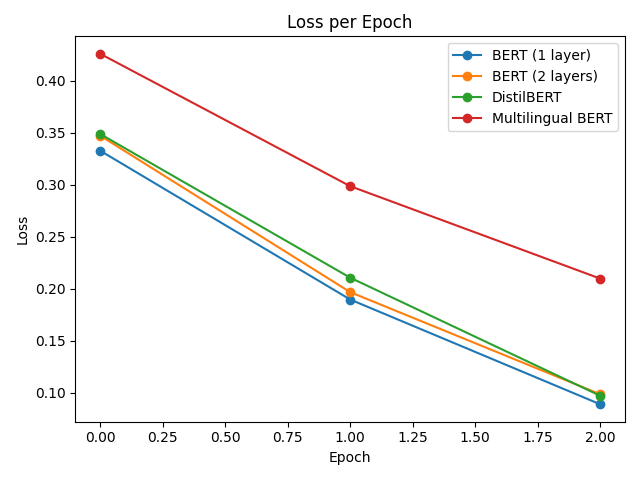








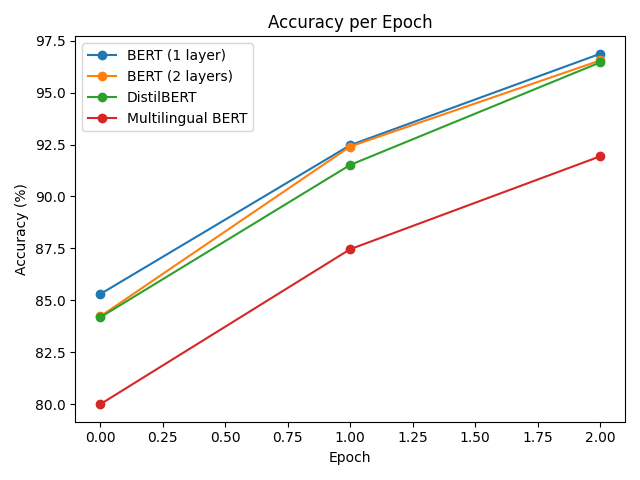

The plots show that during training, all models improve: accuracy increases and loss decreases with each epoch. This means the models are learning well from the training data. BERT and DistilBERT learn faster and reach higher performance, while Multilingual BERT improves more slowly and stays lower. However, when comparing this with the test results, we can see that the models perform worse on unseen data than on training data. This is a sign that some overfitting is happening. To achieve higher test accuracy, further hyperparameter tuning (such as adjusting batch size, learning rate, or regularization) would be needed, which could be an interesting direction to gain deeper understanding of transformer models.

# Experiment 1: Model Generalization

In [ ]:
# This is the simplest model that doesnt have metric of stars:
dataset = load_dataset("amazon_polarity")

# This should work nicely for a standard model ( as normally it is too much)
subset_test = 2000

# just for visualization
x_train = dataset["train"]["content"]
y_train = dataset["train"]["label"]

x_test = dataset["test"]["content"]
y_test = dataset["test"]["label"]

print("size of dataset:",len(x_train))
print("size of dataset:",len(x_test))

x_test = x_test[:subset_test]
y_test = y_test[:subset_test]

print("size of sub-dataset:",len(x_test))

In [ ]:
# To load the data in the model (we are only interested on dataset_test as we are seeing how good the model generalizes)
dataset_test = lanextdataset(x_test,y_test)
dataloader_test_experiment = DataLoader(dataset_test, batch_size=6, shuffle=False)

In [ ]:
modelBert = Sentiment('bert-base-uncased')
modelBert = modelBert.to(device)

# We train it on our Films data
modelBert.fit(dataloader)
training = modelBert.score(dataloader)

# to get the results of training i expect 99% accuracy
print("\nTrain Data:")
print("Bert + IMBD Dataset:", training)

# we test it on our reviews data, i expect 60 / 70 % accuracy
score = modelBert.score(dataloader_test_experiment)
print("\nTest Data:")
print("Bert + different dataset:", score)


# Discussion Experiment 1

In this experiment I explored generalization in sentiment classification using a BERT-based model. The model was trained on 10,000 IMDB movie reviews and evaluated on both an in domain test set (2,000 IMDB samples) and a out of domain test set of equal size (2,000 Amazon reviews). The model achieved 96.81% accuracy on the training data and 85.35% on the Amazon dataset.

The almost identical performance suggests that the model captures largely domain independent sentiment features. However, this needs to be interpreted with caution, as outcomes may vary depending on the specific test samples used, especially with relatively small datasets. Overall, this provides an indication that BERT can generalize well across domains, although further validation would be needed for stronger conclusions.

# Experiment 2: Multilingual Representation

In [ ]:
# for our vector space investigation
dataset_multilingual = load_dataset("opus100", "en-es")

# checking the quantity that we have in our datasets
print(len(dataset_multilingual["train"]))
print(len(dataset_multilingual["test"]))

In [ ]:
english = []
spanish = []

# I decided than doing it too big would be problematic and non efficient for the model
# so I added an stop condition
subset = 1000
count = 0

# We get Spanish and English for the dataset to examine:
for sentence in dataset_multilingual["train"]["translation"]:
  if sentence["en"] and sentence["es"]:
    english.append(sentence["en"])
    spanish.append(sentence["es"])
    count += 1
  if count == subset:
    break


print("Dataset from English:",len(english),"\nDataset from Spanish:" ,len(spanish))



In [ ]:
tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-cased')
experiment2 = BertModel.from_pretrained("bert-base-multilingual-cased")

"""
I tried doing like this but the GPU was collapising as i was directly passing 1000 values so i changed it to dataset and dataloader


Making sure that both datas have the same space to avoid missmatches on the size and we trucate them.

encoded_inputsp = tokenizer(spanish, padding = True, truncation = True, return_tensors='pt')
encoded_inputen = tokenizer(english, padding = True, truncation = True,  return_tensors='pt')

# This is how it looks in the documentation i dont understand the **

output_sp = experiment2(**encoded_inputsp)
output_en = experiment2(**encoded_inputen)

# We do the same as we did in our forward pass to get the values that we need for our model:

hidden_sp = output_sp.last_hidden_state
hidden_en = output_en.last_hidden_state

pooled_output_sp = hidden_sp[:, 0, :]
pooled_output_en = hidden_en[:, 0, :]

# we get the matrix from our embedding data
sp = np.array(pooled_output_sp).detach().cpu().numpy()
en = np.array(pooled_output_en).detach().cpu().numpy()

print(sp.shape)
print(en.shape)
"""


In [ ]:
# Here we do our basic Dataset based on the structure of the manual :
class lanextdataset2(Dataset):
    def __init__(self, sentences):
        self.sentences = sentences

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, idx):
        return self.sentences[idx]


batch_size = 4

# We load the data
spanish_dataset = lanextdataset2(spanish)
english_dataset = lanextdataset2(english)

# we get the dataloader
sp_results = DataLoader(spanish_dataset, batch_size=batch_size, shuffle=False)
en_results = DataLoader(english_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
spanish_embeddings = []
english_embeddings = []

for batch in sp_results:

  # The same as we did with the class
  encoded_inputsp = tokenizer(batch, padding = True, truncation = True, return_tensors='pt')
  output_sp = experiment2(**encoded_inputsp)
  hidden_sp = output_sp.last_hidden_state

  # we get the cls (vector per sentence)
  pooled_output_sp = hidden_sp[:, 0, :]

  # we compute it into an array and save it into the list , tensor  , we detach it , then we apply np

  sp = (pooled_output_sp).detach().cpu().numpy()
  spanish_embeddings.append(sp)

# to get the shape
print("Dimensionality per batch:")
print(sp.shape)

# we follow the sams structure for theh english side of the data:
for batch in en_results:
  encoded_inputen = tokenizer(batch, padding = True, truncation = True,  return_tensors='pt')
  output_en = experiment2(**encoded_inputen)
  hidden_en = output_en.last_hidden_state

  pooled_output_en = hidden_en[:, 0, :]
  en = (pooled_output_en).detach().cpu().numpy()
  english_embeddings.append(en)

print("Dimensionality per batch:")
print(en.shape)

In [ ]:
# to get the whole matrix for both languages
spanish_matrix = np.concatenate(spanish_embeddings)
english_matrix = np.concatenate(english_embeddings)

# to observe everything is correct
print("Dimensionality of the matrix:")
print(spanish_matrix.shape)
print(english_matrix.shape)

In [ ]:
# Here we add all the datapoints into a shared space to see proximity:
total_space = np.concatenate((spanish_matrix,english_matrix))
all_sentences = spanish + english

print("Dimensionality of the matrix:")
print(total_space.shape)


In [ ]:
# Same structure as it was discussed in the previous work:

nbrs = NearestNeighbors(n_neighbors=3, algorithm='ball_tree').fit(total_space)
distances, indices = nbrs.kneighbors([total_space[0]])

# we get the sentences from english for teh analysis
for i in range(3):

    # th eindex of english are the last sentences
    idx = 1000 + i

    distances, indices = nbrs.kneighbors([total_space[idx]])

    print(f"\nSentence: {all_sentences[idx]}")
    print("Closest sentences:")

    for neighbor_idx in indices[0]:
        print(all_sentences[neighbor_idx])

# The results clearly show ( if i didnt do anything wrong,
# that multillinugual bert distinguishes languages and is
# putting them in different regions of the vector space )

In [ ]:
# Same structure as it was discussed in the previous work:

nbrs = NearestNeighbors(n_neighbors=3, algorithm='ball_tree').fit(total_space)
distances, indices = nbrs.kneighbors([total_space[0]])

# we get the sentences from english for teh analysis
for i in range(3):

    idx = 0 + i
    distances, indices = nbrs.kneighbors([total_space[idx]])

    print(f"\nSentence: {all_sentences[idx]}")
    print("Closest sentences:")

    for neighbor_idx in indices[0]:
        print(all_sentences[neighbor_idx])

# Discussion Experiment 2

The results show that sentences were grouped by language rather than by meaning. English sentences tend to be closest to other English sentences, and Spanish sentences to Spanish ones, even when they are translations of each other. This suggests that since the model is trained on multiple languages focuses more on surface features instead of crosslingual meaning as I was expecting. As a result, the embeddings do not strongly align equivalent sentences across languages in this setup.